<span style="float: left;padding: 1.3em">![logo](https://github.com/gw-odw/odw/blob/main/Tutorials/logo.png?raw=1)</span>

# Gravitational Wave Open Data Workshop

## Challenge 1 (Novice)


Identify a loud binary black hole signal in white, Gaussian noise.


*   Use the data file challenge1.gwf. The channel name is H1:CHALLENGE1.
*   The data are white, Gaussian noise containing a simulated BBH signal.



1.  Load the data into memory. What are the sampling rate and duration of the data?
2.  Plot the data in the time-domain.
3.  Plot a spectrogram (or q-transform) of the data, and try to identify the signal.
4.   What is the time of the merger?














In [ ]:
# Those 2 lines are just to avoid some harmless warnings when importing packages
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

> ⚠️ **Warning**: restart the runtime after running the cell below.
>
> To do so, click "Runtime" in the menu and choose "Restart and run all".

In [ ]:
# -- Use the following for Google Colab
! pip install -q "lalsuite==7.25.1"
! pip install --no-build-isolation pycbc
!pip install numpy==1.23.5
! pip install -q 'gwosc==0.7.1'

# Section 1: Load the data into memory.

In [ ]:
! pip install -q lalsuite
! pip install -q gwpy
! pip install -q pycbc
# -- Click "restart runtime" in the runtime menu

# -- download data
! wget https://dcc.ligo.org/public/0187/G2300818/001/challenge1.gwf

# -- for gwpy
from gwpy.timeseries import TimeSeries
gwpy_strain = TimeSeries.read('challenge1.gwf', channel="H1:CHALLENGE1")

# -- for pycbc
from pycbc import frame
pycbc_strain = frame.read_frame('challenge1.gwf', 'H1:CHALLENGE1')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 7.8 MB/s eta 0:00:00
--2025-05-20 18:16:52--  https://dcc.ligo.org/public/0187/G2300818/001/challenge1.gwf
Resolving dcc.ligo.org (dcc.ligo.org)... 131.215.125.133
Connecting to dcc.ligo.org (dcc.ligo.org)|131.215.125.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4025680 (3.8M)
Saving to: ‘challenge1.gwf’

challenge1.gwf      100%[===================>]   3.84M  --.-KB/s    in 0.1s    

2025-05-20 18:16:52 (31.5 MB/s) - ‘challenge1.gwf’ saved [4025680/4025680]



In [ ]:
#from google.colab import files
#uploaded = files.upload()


In [ ]:
#file_path = "challenge1.gwf"  # nombre después de subirlo
#ts = read_frame(file_path, "H1:CHALLENGE1")

# 1. What are the sampling rate and duration of the data?

In [ ]:
print("Sample rate:", gwpy_strain.sample_rate)

Sample rate: 4096.0 Hz


In [ ]:
print("Duration:", gwpy_strain.duration)

Duration: 128.0 s


#2. Plot the data in the time-domain.

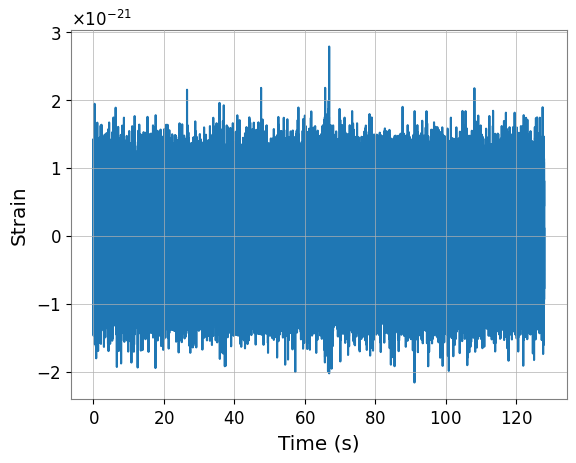

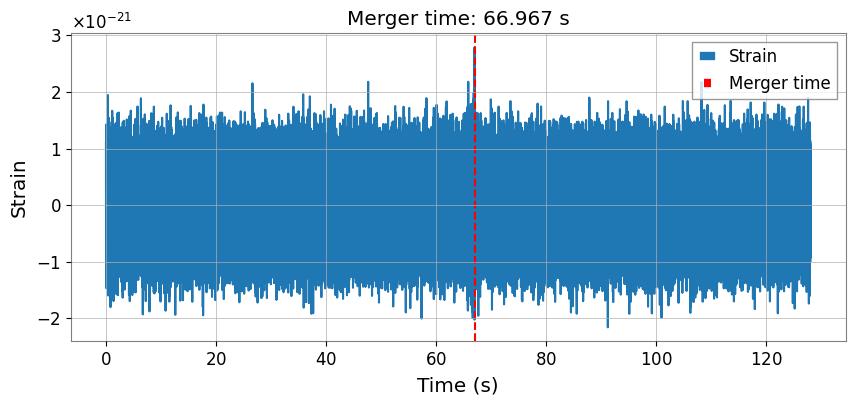

In [ ]:
import matplotlib.pyplot as plt
plt.plot(pycbc_strain.sample_times, pycbc_strain)
plt.xlabel('Time (s)')
plt.ylabel('Strain')
plt.show()


# To identify Merger Time:

plt.figure(figsize=(10, 4))
plt.plot(gwpy_strain.times.value, gwpy_strain.value, label="Strain")
plt.axvline(peak_time.value, color='red', linestyle='--', label='Merger time')
plt.xlabel('Time (s)')
plt.ylabel('Strain')
plt.legend()
plt.title(f"Merger time: {peak_time.value:.3f} s")
plt.show()

# 3. Plot a spectrogram (or q-transform) of the data, and try to identify the signal.

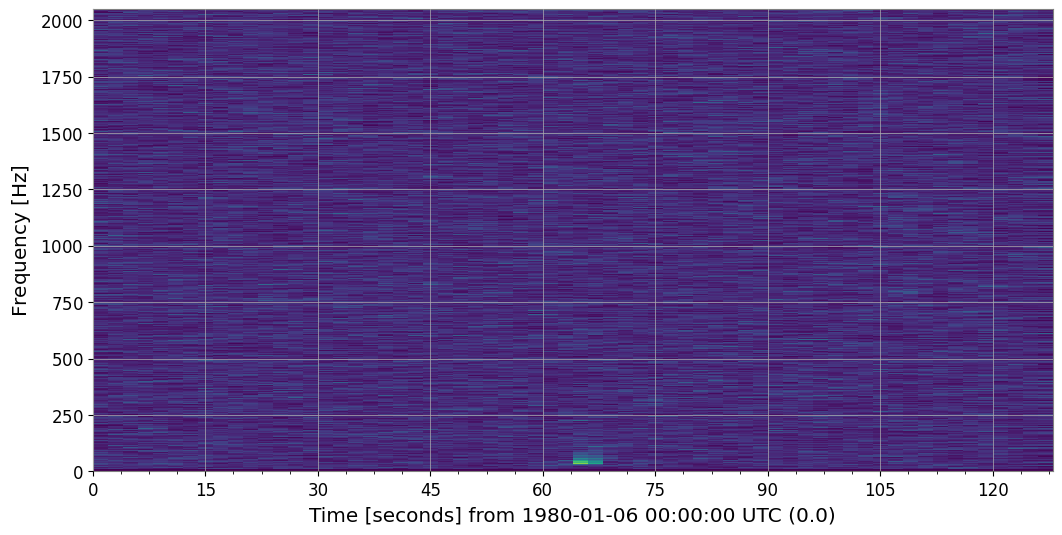

In [ ]:
from pycbc.types import TimeSeries
from gwpy.timeseries import TimeSeries as gwpy_TimeSeries


specgram = gwpy_strain.spectrogram2(fftlength=4, overlap=2, window='hann') ** (1/2.)

plot = specgram.plot()
plt.show()

In [ ]:
#To adjust the scale of the graph.
# We need the min and max values ​​of the spectrogram.
print("Min:", specgram.min())
print("Max:", specgram.max())

Min: 4.488426471649459e-15 ct(1/2) / Hz(1/4)
Max: 8.762964778122077e-12 ct(1/2) / Hz(1/4)


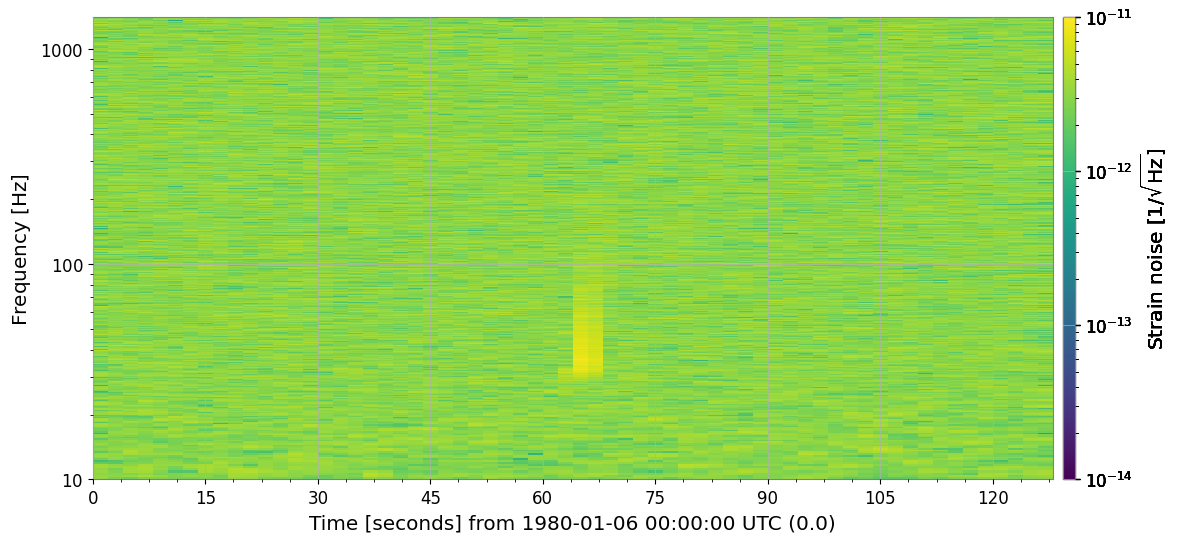

In [ ]:
ax = plot.gca()
ax.set_yscale('log')
ax.set_ylim(10, 1400)
ax.colorbar(
    clim=(1e-14, 1e-11),
    norm="log",
    label=r"Strain noise [$1/\sqrt{\mathrm{Hz}}$]",
)
plot  # refresh


# 4. What is the time of the merger?

In [ ]:
peak_time = gwpy_strain.times[abs(gwpy_strain).argmax()]
print("Time of Merger:", peak_time)

Time of Merger: 66.966552734375 s


In [ ]:
#Due to white noise:

filtered = gwpy_strain.bandpass(30, 300)

peak_time_filtered = filtered.times[abs(filtered).argmax()]
print("Time of merger:", peak_time_filtered)

Time of merger: 66.959716796875 s
